Import the libraries.

In [30]:
import numpy as np
import pandas as pd

Load the dataset.

In [31]:
df = pd.read_csv('../Datasets/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [32]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

Scale the data.

In [33]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [34]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


Model structure.

In [35]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/home/hardik/Documents/learning_code/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
X.shape

(400, 2)

Compile the model and train it using BATCH GD method.

In [ ]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=50,batch_size=df.shape[0],validation_split=0.2)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step - accuracy: 0.4281 - loss: 0.6789 - val_accuracy: 0.6750 - val_loss: 0.5981
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4594 - loss: 0.6673 - val_accuracy: 0.7125 - val_loss: 0.5958
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5188 - loss: 0.6589 - val_accuracy: 0.7375 - val_loss: 0.5938
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.6469 - loss: 0.6518 - val_accuracy: 0.7500 - val_loss: 0.5921
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7031 - loss: 0.6456 - val_accuracy: 0.7750 - val_loss: 0.5904
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7563 - loss: 0.6398 - val_accuracy: 0.7750 - val_loss: 0.5889
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8125 - loss: 0.6345 - val_accuracy: 0.7875 - val_loss: 0.5875
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8219 - loss: 0.6295 - val_accuracy: 0.7875 - val_loss: 

Plot the loss and corresponding cross validation score for each epochs.

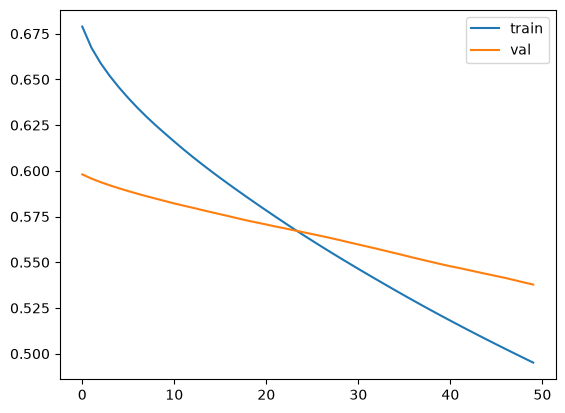

In [38]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='val')
plt.legend()

Compile the model and train it using STOCASTIC GD method.

In [39]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=50,batch_size=1,validation_split=0.2)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8500 - loss: 0.3865 - val_accuracy: 0.8875 - val_loss: 0.4686
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8531 - loss: 0.3177 - val_accuracy: 0.9125 - val_loss: 0.4013
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.2959 - val_accuracy: 0.9000 - val_loss: 0.3706
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8625 - loss: 0.2906 - val_accuracy: 0.9500 - val_loss: 0.3324
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8625 - loss: 0.2835 - val_accuracy: 0.9375 - val_loss: 0.3149
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.2832 - val_accuracy: 0.9500 - val_loss: 0.2977
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8750 - loss: 0.2783 - val_accuracy: 0.9625 - val_loss: 0.2800
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8719 - loss: 0.2804 - val_accuracy: 0.

Plot the loss and corresponding cross validation score for each epochs.

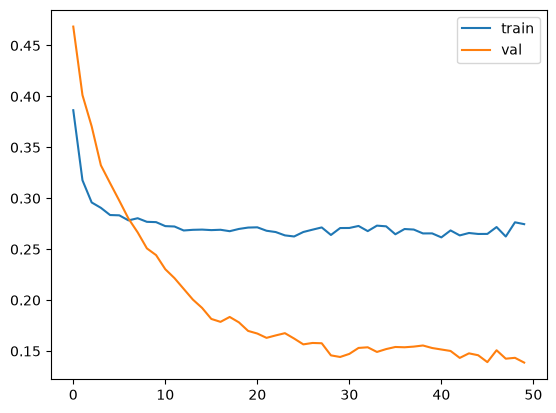

In [40]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='val')
plt.legend()

Compile the model and train it using MINI BATCH GD method.

In [45]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.9062 - loss: 0.2297 - val_accuracy: 0.9375 - val_loss: 0.2328
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9094 - loss: 0.2293 - val_accuracy: 0.9375 - val_loss: 0.2317
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9094 - loss: 0.2292 - val_accuracy: 0.9375 - val_loss: 0.2357
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9062 - loss: 0.2289 - val_accuracy: 0.9375 - val_loss: 0.2341
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9094 - loss: 0.2288 - val_accuracy: 0.9375 - val_loss: 0.2343
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9094 - loss: 0.2289 - val_accuracy: 0.9375 - val_loss: 0.2310
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9094 - loss: 0.2288 - val_accuracy: 0.9375 - val_loss: 0.2322
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9094 - loss: 0.2288 - val_accuracy: 0.9375 - val_loss: 0.

Plot the loss and corresponding cross validation score for each epochs.

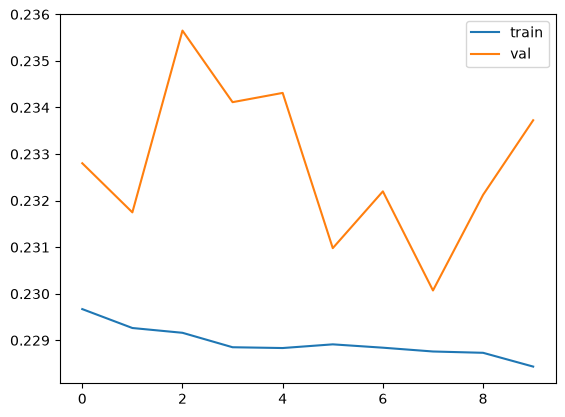

In [46]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='val')
plt.legend()